# EDA: data inventory

what data exists, is it broken, and what are the basic quality metrics?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import pyreadr

Image.MAX_IMAGE_PIXELS = None  # WSI thumbnails are legitimately large

ROOT = Path().resolve().parents[1]
DATA = ROOT / 'data' / 'inputs'

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

## 1. clinical metadata
load patient-level clinical data and check completeness. paper (p13): 94 patients, 54 clinical/molecular columns.

In [2]:
clinical = pd.read_excel(DATA / 'Clinical' / 'Clinical.xlsx')
print(f'patients: {len(clinical)}')
print(f'columns: {list(clinical.columns)}')
clinical.head()

patients: 94
columns: ['ST_TNBC_ID', 'Age_at_diagnosis', 'Staging_pTNM', 'T_TNM', 'N_TNM', 'Grade', 'ER.IHC', 'PR.IHC', 'HER2.IHC', 'Ki67_percentage', 'LN.status', 'Number.of.LN.involvment', 'Germline.mutation', 'CT_ADJ', 'RT_ADJ', 'Days_between_diagnosis_to_last.follow.up', '1st.Local_Relapse', '1st.Local_Relapse_location', 'Days_between_diagnosis_and_ 1st.Local_Relapse', '1st_Local_Relapse.histology', '2nd.Local_Relapse', '2nd.Local_Relapse_location', '2nd.Local_Relapse_DATE', '2nd.Local_Relapse.histology', 'Distant_Relapse', 'Days_between_diagnosis_and_ Distant.Relapse', 'Distant.relapse_location', 'Distant.Relapse.histology', 'Other_primary_cancer', 'Days_between_diagnosis_and_ Other_primary_cancer', 'Other_primary_cancer_location', 'Death', 'Days_between_diagnosis_and_ Death', 'Death.related.to.breast.cancer', 'RFS-event', 'RFS_years', 'iBCFS-event', 'iBCFS_years', 'iDFS-event', 'iDFS_years', 'DRFS-event', 'DRFS_years', 'OS-event', 'OS_years', 'TIME_classes.by.pathologist', 'sTILs

,ST_TNBC_ID,Age_at_diagnosis,Staging_pTNM,T_TNM,N_TNM,Grade,ER.IHC,PR.IHC,HER2.IHC,Ki67_percentage,...,TIME_classes.by.pathologist,sTILs.percentage.bypathologist,CD3.percentage.bypathologist,CD20.percentage.by pathologist,TIME_classes_expression_bulk,TIME_classes_expression_global_pseudobulk,Bareche_molecular_subtype_defined_on_global_pseudobulk,Bareche_molecular_subtype_defined_on_tumor_pseudobulk,Bareche_molecular_subtype_defined_on_stroma_pseudobulk,Spatial archetypes_defined_on_ST_global_pseudobulk
0,1,66,pT1cN0,1,0,3,0,0,0,40.0,...,MR,5.0,5.0,0.0,Margin restricted,Margin restricted,LAR,LAR,LAR,5
1,10,57,pT2N0,2,0,3,0,0,0,40.0,...,nd,NaN,NaN,NaN,Margin restricted,Fully Inflamed,MSL,LAR,MSL,5
2,11,67,pT2N2a,2,2,3,0,0,0,20.0,...,SR,5.0,5.0,0.0,Margin restricted,Margin restricted,LAR,LAR,LAR,5
3,12,61,pT1cN0,1,0,3,0,0,0,20.0,...,SR,15.0,14.0,1.0,Margin restricted,Margin restricted,M,M,MSL,6
4,13,72,pT3N2a,3,2,2,0,0,0,5.0,...,ID,0.0,0.0,0.0,Margin restricted,Margin restricted,LAR,LAR,LAR,5


In [3]:
# missingness
clinical.isnull().sum()[clinical.isnull().sum() > 0]

Ki67_percentage                                      1
RT_ADJ                                               1
1st.Local_Relapse                                    2
1st.Local_Relapse_location                          78
Days_between_diagnosis_and_ 1st.Local_Relapse       78
1st_Local_Relapse.histology                         78
2nd.Local_Relapse                                   93
2nd.Local_Relapse_location                          93
2nd.Local_Relapse_DATE                              93
2nd.Local_Relapse.histology                         93
Distant_Relapse                                      2
Days_between_diagnosis_and_ Distant.Relapse         81
Distant.relapse_location                            81
Distant.Relapse.histology                           89
Other_primary_cancer                                 2
Days_between_diagnosis_and_ Other_primary_cancer    91
Other_primary_cancer_location                       91
Death                                                2
Days_betwe

## 2. array structure + pairing
map the physical hierarchy: slides -> arrays -> subarrays -> files per subarray. paper (p13): each slide has 6 subarrays (C1/C2, D1/D2, E1/E2).

In [4]:
# how many arrays, subarrays, and what files per subarray
arrays = sorted([d for d in (DATA / 'byArray').iterdir() if d.is_dir()])
print(f'arrays: {len(arrays)}')

# count subarrays
total_subarrays = 0
for arr in arrays:
    subs = [d for d in arr.iterdir() if d.is_dir()]
    total_subarrays += len(subs)
print(f'total subarrays: {total_subarrays}')

# sample one subarray
first_sub = sorted([d for d in arrays[0].iterdir() if d.is_dir()])[0]
print(f'\nfiles in {arrays[0].name}/{first_sub.name}:')
for f in sorted(first_sub.iterdir()):
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')

arrays: 47
total subarrays: 282

files in CN1/C1:
  190204_Diamond_CN1_C1_TNBC1_HE-Spot000001_small.jpg (11774 KB)
  190215_CN1_C1_TNBC1_Cy3-Spot000001_small.jpg (5139 KB)
  all.RData (9580 KB)
  allSpots.RDS (24 KB)
  annotBySpot.RDS (24 KB)
  selection.RData (6703 KB)
  selectionSpots.RDS (14 KB)
  small.jpg (351 KB)
  spot_data-all-190215_CN1_C1_TNBC1_Cy3-Spot000001_small.tsv (68 KB)
  spot_data-selection-190215_CN1_C1_TNBC1_Cy3-Spot000001_small.tsv (33 KB)
  transformation_matrix190215_CN1_C1_TNBC1_Cy3-Spot000001_small.txt (0 KB)


## 3. H&E thumbnails - visual check
quick visual scan of H&E staining quality, tissue coverage, and obvious artifacts across a sample of arrays.

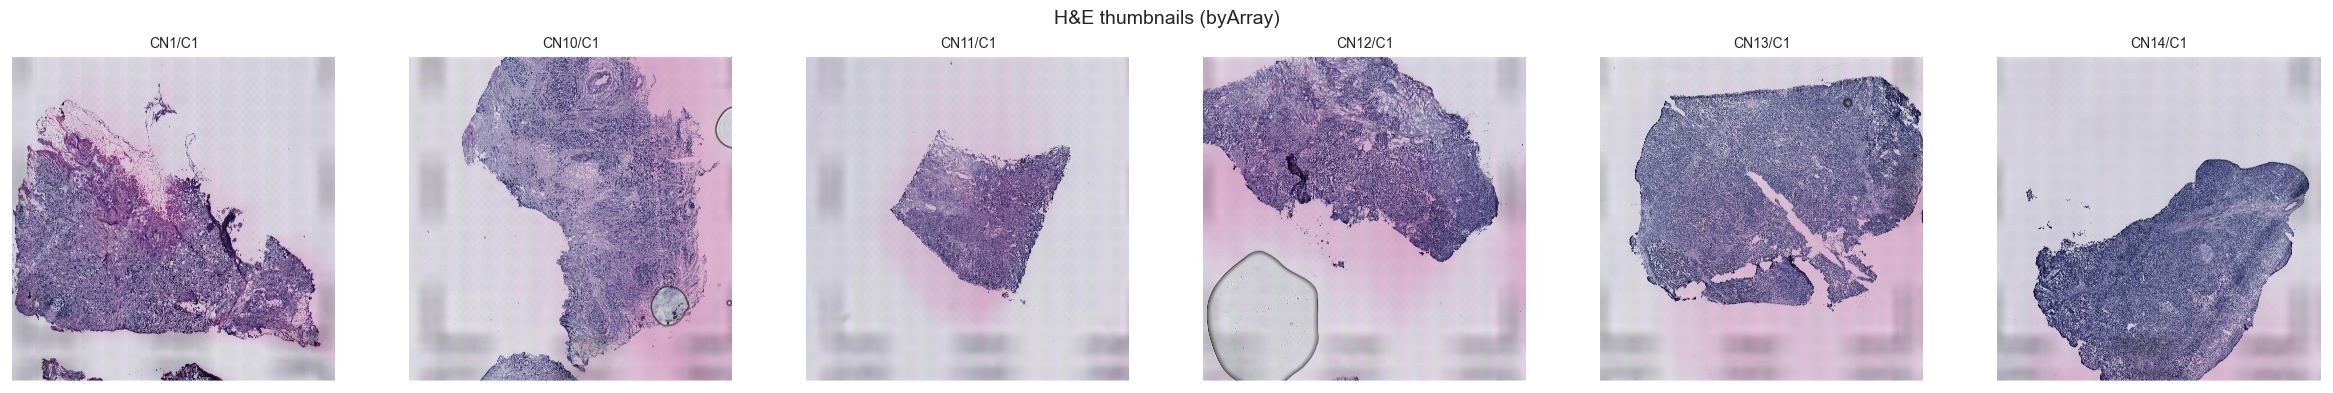

In [5]:
# grab a few H&E thumbnails across arrays
he_images = []
for arr in arrays[:6]:
    subs = sorted([d for d in arr.iterdir() if d.is_dir()])
    if subs:
        he = list(subs[0].glob('*HE*small*')) + list(subs[0].glob('small.jpg'))
        if he:
            he_images.append((arr.name, subs[0].name, he[0]))

fig, axes = plt.subplots(1, len(he_images), figsize=(4*len(he_images), 4))
for ax, (arr, sub, path) in zip(axes, he_images):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f'{arr}/{sub}', fontsize=10)
    ax.axis('off')
plt.suptitle('H&E thumbnails (byArray)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. ST count matrix - single array deep dive
load one count matrix to understand format, dimensions, sparsity, and value range. paper (p3): 1934 barcoded spots per array, median 2554 genes/spot.

In [6]:
# pick one count matrix
count_files = sorted([f for f in (DATA / 'rawCountsMatrices').iterdir() if f.suffix == '.bz2'])
print(f'count matrix files: {len(count_files)}')
print(f'first few: {[f.name for f in count_files[:5]]}')

# load one
df = pd.read_csv(count_files[0], sep='\t', compression='bz2', index_col=0)
print(f'\n{count_files[0].name}:')
print(f'  spots (rows): {df.shape[0]}')
print(f'  genes (cols): {df.shape[1]}')
print(f'  total counts per spot: median={df.sum(axis=1).median():.0f}, min={df.sum(axis=1).min():.0f}, max={df.sum(axis=1).max():.0f}')
print(f'  genes detected per spot: median={(df > 0).sum(axis=1).median():.0f}')
print(f'  sparsity: {(df == 0).sum().sum() / df.size:.2%}')

count matrix files: 281
first few: ['P13202_1001_S1_L001_stdata.tsv.bz2', 'P13202_1002_S2_L001_stdata.tsv.bz2', 'P13202_1003_S3_L001_stdata.tsv.bz2', 'P13202_1004_S4_L001_stdata.tsv.bz2', 'P13202_1005_S5_L001_stdata.tsv.bz2']

P13202_1001_S1_L001_stdata.tsv.bz2:
  spots (rows): 1934
  genes (cols): 30270
  total counts per spot: median=6729, min=296, max=72373
  genes detected per spot: median=2516
  sparsity: 89.39%


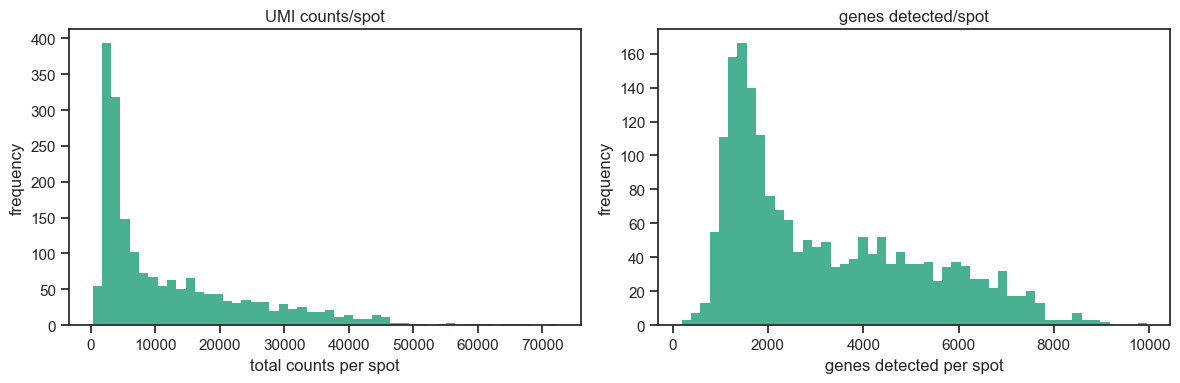

In [7]:
# counts per spot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.sum(axis=1), bins=50, edgecolor='none', alpha=0.8)
axes[0].set_xlabel('total counts per spot')
axes[0].set_ylabel('frequency')
axes[0].set_title('UMI counts/spot')

axes[1].hist((df > 0).sum(axis=1), bins=50, edgecolor='none', alpha=0.8)
axes[1].set_xlabel('genes detected per spot')
axes[1].set_ylabel('frequency')
axes[1].set_title('genes detected/spot')

plt.tight_layout()
plt.show()

## 5. spot coordinates - spatial layout
verify that spot coordinate files exist and show the expected ST grid pattern. paper (p3): 1934 barcoded spots/array, 100um diameter, 200um center-to-center (original Spatial Transcriptomics, Stahl et al. 2016, KTH/Spatial Transcriptomics AB - not 10x Visium).

In [8]:
# check spot_data files for spatial coordinates
sample_arr = arrays[0]
sample_sub = sorted([d for d in sample_arr.iterdir() if d.is_dir()])[0]
spot_files = list(sample_sub.glob('spot_data*'))
print(f'spot files in {sample_arr.name}/{sample_sub.name}:')
for f in spot_files:
    print(f'  {f.name}')

# load one
if spot_files:
    spots = pd.read_csv(spot_files[0], sep='\t')
    print(f'\ncolumns: {list(spots.columns)}')
    print(f'spots: {len(spots)}')
    spots.head()

spot files in CN1/C1:
  spot_data-selection-190215_CN1_C1_TNBC1_Cy3-Spot000001_small.tsv
  spot_data-all-190215_CN1_C1_TNBC1_Cy3-Spot000001_small.tsv

columns: ['x', 'y', 'new_x', 'new_y', 'pixel_x', 'pixel_y']
spots: 1075


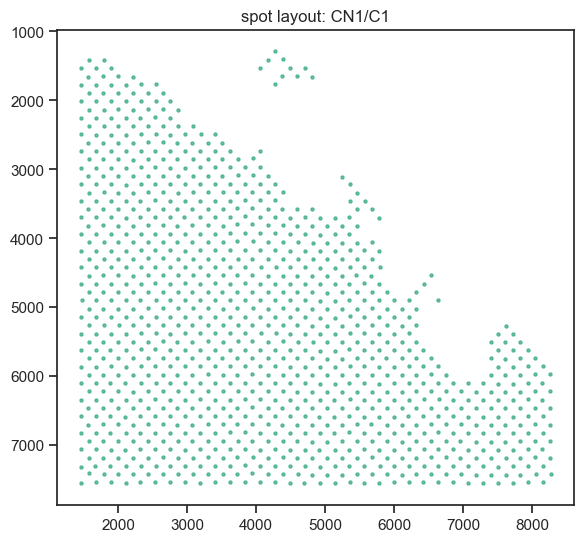

In [9]:
# plot spot layout if we have pixel coords
if spot_files and 'pixel_x' in spots.columns:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(spots['pixel_x'], spots['pixel_y'], s=5, alpha=0.6)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(f'spot layout: {sample_arr.name}/{sample_sub.name}')
    plt.tight_layout()
    plt.show()

## 6. cross-array summary stats
load all 281 count matrices and compute per-array QC metrics to identify batch effects and outliers. paper (p15): 281 high-quality subarrays from 288 performed.

In [10]:
# summarize across all count matrices - use pandas for speed
stats = []
for i, f in enumerate(count_files):
    try:
        d = pd.read_csv(f, sep='\t', compression='bz2', index_col=0)
        row_sums = d.values.sum(axis=1)
        row_detected = (d.values > 0).sum(axis=1)
        stats.append({
            'file': f.name,
            'spots': d.shape[0],
            'genes': d.shape[1],
            'median_umi': np.median(row_sums),
            'median_genes_detected': np.median(row_detected),
            'min_umi': row_sums.min(),
            'max_umi': row_sums.max(),
        })
    except Exception as e:
        stats.append({'file': f.name, 'error': str(e)})
    if (i + 1) % 50 == 0:
        print(f'  processed {i + 1}/{len(count_files)}...')

stats_df = pd.DataFrame(stats)
errors = stats_df['error'].dropna() if 'error' in stats_df.columns else pd.Series()
print(f'\nloaded: {len(stats_df) - len(errors)} / {len(stats_df)}')
if len(errors) > 0:
    print(f'failed: {len(errors)}')
    print(errors.values)
stats_df.drop(columns=['file', 'error'], errors='ignore').describe()

  processed 50/281...
  processed 100/281...
  processed 150/281...
  processed 200/281...
  processed 250/281...

loaded: 281 / 281


,spots,genes,median_umi,median_genes_detected,min_umi,max_umi
count,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000
mean,1933.918149,27989.800712,3952.243772,1570.185053,272.231317,52520.601423
std,0.864204,2789.779939,2973.114053,834.944235,252.008801,26283.050633
min,1920.000000,17757.000000,81.000000,67.000000,1.000000,420.000000
25%,1934.000000,26238.000000,1720.500000,929.500000,83.000000,36490.000000
50%,1934.000000,27616.000000,3160.000000,1460.500000,203.000000,47604.000000
75%,1934.000000,29259.000000,5314.000000,2036.000000,400.000000,63465.000000
max,1934.000000,36682.000000,16748.500000,4918.500000,1262.000000,168093.000000


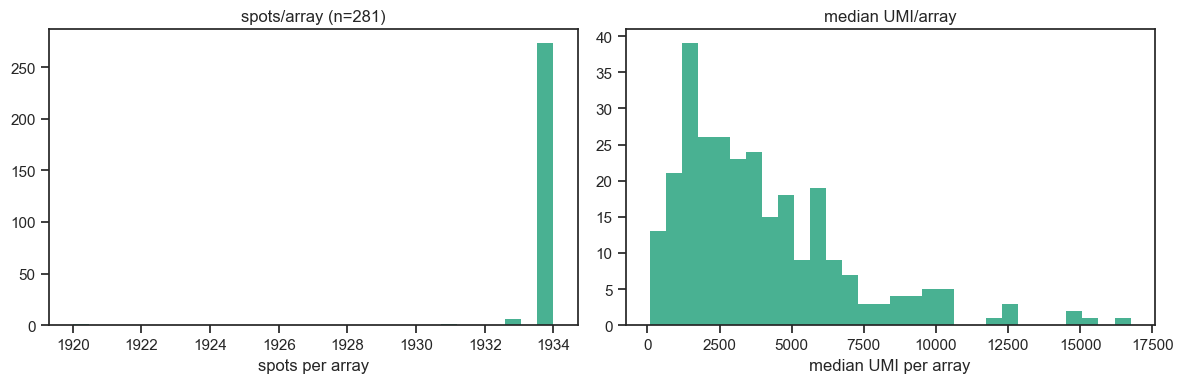

In [11]:
# distribution of spots per array and median UMI per array
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(stats_df['spots'].dropna(), bins=30, edgecolor='none', alpha=0.8)
axes[0].set_xlabel('spots per array')
axes[0].set_title(f'spots/array (n={len(stats_df)})')

axes[1].hist(stats_df['median_umi'].dropna(), bins=30, edgecolor='none', alpha=0.8)
axes[1].set_xlabel('median UMI per array')
axes[1].set_title('median UMI/array')

plt.tight_layout()
plt.show()

## 7. outlier detection
flag arrays with anomalous spot counts, UMI depth, or gene detection using IQR-based thresholds.

In [12]:
# flag outlier arrays
clean = stats_df.dropna(subset=['spots'])
for col in ['spots', 'median_umi', 'median_genes_detected']:
    q1, q3 = clean[col].quantile(0.25), clean[col].quantile(0.75)
    iqr = q3 - q1
    low = clean[clean[col] < q1 - 1.5 * iqr]
    high = clean[clean[col] > q3 + 1.5 * iqr]
    if len(low) > 0 or len(high) > 0:
        print(f'{col}: {len(low)} low outliers, {len(high)} high outliers')
        if len(low) > 0:
            print(f'  low: {low[["file", col]].values.tolist()}')
        if len(high) > 0:
            print(f'  high: {high[["file", col]].values.tolist()}')
    else:
        print(f'{col}: no outliers')

spots: 8 low outliers, 0 high outliers
  low: [['P13202_3036_S176_L003_stdata.tsv.bz2', 1933], ['P13202_3043_S183_L003_stdata.tsv.bz2', 1933], ['P13202_3046_S186_L003_stdata.tsv.bz2', 1933], ['P13202_3047_S187_L003_stdata.tsv.bz2', 1931], ['P13202_3048_S188_L003_stdata.tsv.bz2', 1920], ['P13202_3066_S206_L003_stdata.tsv.bz2', 1933], ['P13202_4029_S239_L004_stdata.tsv.bz2', 1933], ['P13202_4031_S241_L004_stdata.tsv.bz2', 1933]]
median_umi: 0 low outliers, 8 high outliers
  high: [['P13202_2001_S71_L002_stdata.tsv.bz2', 16748.5], ['P13202_2002_S72_L002_stdata.tsv.bz2', 15296.0], ['P13202_2003_S73_L002_stdata.tsv.bz2', 14885.5], ['P13202_3012_S152_L003_stdata.tsv.bz2', 11973.5], ['P13202_4022_S232_L004_stdata.tsv.bz2', 14738.0], ['P13202_4032_S242_L004_stdata.tsv.bz2', 12319.5], ['P13202_4033_S243_L004_stdata.tsv.bz2', 12491.5], ['P13202_4051_S261_L004_stdata.tsv.bz2', 12843.0]]
median_genes_detected: 0 low outliers, 5 high outliers
  high: [['P13202_2001_S71_L002_stdata.tsv.bz2', 4622.0]

## 8. morphological annotations
the dataset includes expert pathologist annotations per spot (annotBySpot.RDS) mapping pixel fractions to 17 tissue categories + background. these serve as ground truth for validating embedding structure (H2).

In [13]:
import subprocess, io

# count subarrays with morphological annotations
annotated = []
for slide_dir in sorted((DATA / 'byArray').iterdir()):
    if not slide_dir.is_dir():
        continue
    for pos_dir in sorted(slide_dir.iterdir()):
        if not pos_dir.is_dir():
            continue
        if (pos_dir / 'annotBySpot.RDS').exists():
            annotated.append(f'{slide_dir.name}/{pos_dir.name}')

print(f'subarrays with morphological annotations: {len(annotated)} / 281')
print(f'coverage: {len(annotated)/281:.0%} (one per patient)')

# load one and inspect
sample_annot_path = DATA / 'byArray' / 'CN1' / 'C1' / 'annotBySpot.RDS'
r = subprocess.run(
    ['Rscript', '-e', f'x <- readRDS("{sample_annot_path}"); write.csv(x, stdout())'],
    capture_output=True, text=True
)
annot = pd.read_csv(io.StringIO(r.stdout), index_col=0)
print(f'\nmatrix shape: {annot.shape} (spots x categories)')
print(f'\ncategories ({len(annot.columns)}):')
for c in annot.columns:
    nonzero = (annot[c] > 0).sum()
    print(f'  {c}: {nonzero} spots ({nonzero/len(annot):.0%})')

subarrays with morphological annotations: 94 / 281
coverage: 33% (one per patient)

matrix shape: (1931, 18) (spots x categories)

categories (18):
  Nothing: 1683 spots (87%)
  Tumor: 850 spots (44%)
  Necrosis: 0 spots (0%)
  Fat tissue: 288 spots (15%)
  Low TIL stroma: 6 spots (0%)
  Vessels: 14 spots (1%)
  Artefacts: 43 spots (2%)
  Lactiferous duct: 29 spots (2%)
  High TIL stroma: 9 spots (0%)
  in situ: 0 spots (0%)
  Lymphoid nodule: 0 spots (0%)
  Hole (whitespace): 52 spots (3%)
  Lymphocyte: 715 spots (37%)
  Stroma cell: 937 spots (49%)
  Nerve: 0 spots (0%)
  Heterologous elements: 0 spots (0%)
  Acellular stroma: 903 spots (47%)
  Tumor region: 0 spots (0%)


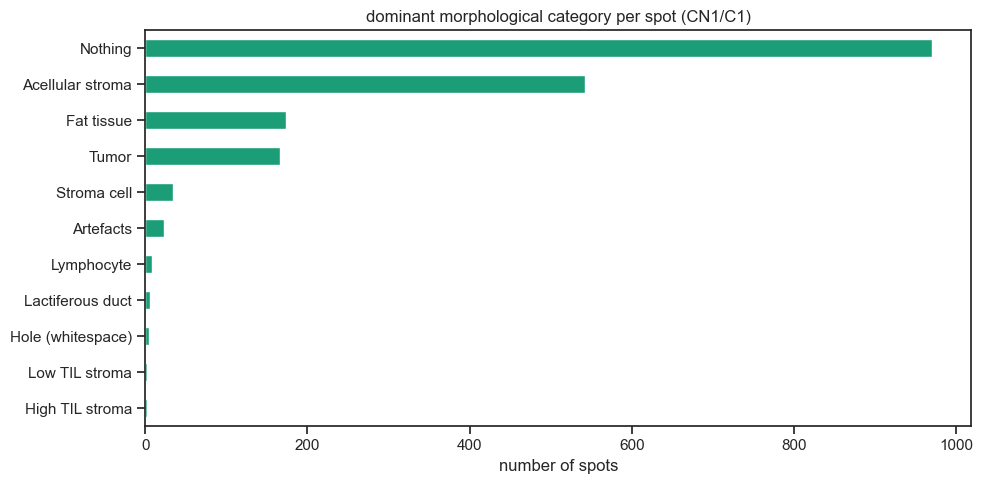

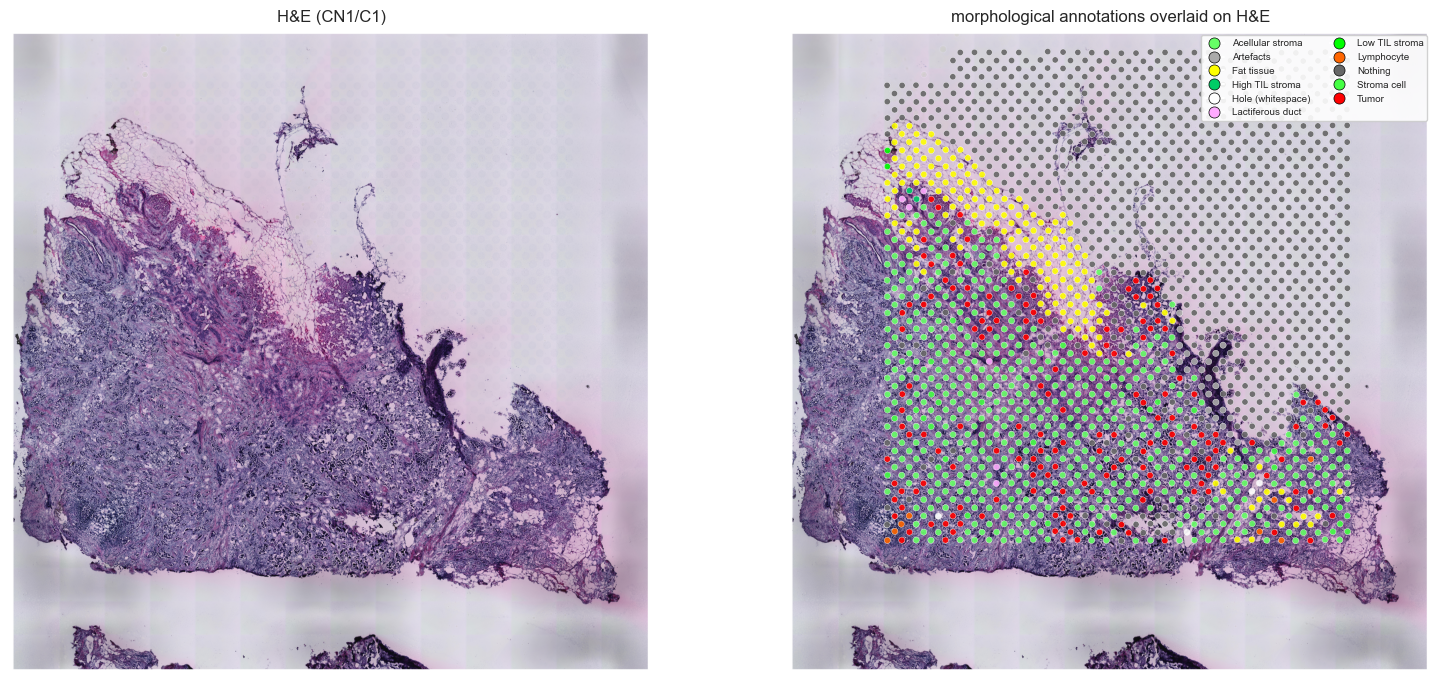

In [18]:
# dominant category per spot (highest pixel fraction)
dominant = annot.idxmax(axis=1)
cat_counts = dominant.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.plot.barh(ax=ax)
ax.set_xlabel('number of spots')
ax.set_title('dominant morphological category per spot (CN1/C1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# overlay annotations on H&E
spot_file = list((DATA / 'byArray' / 'CN1' / 'C1').glob('spot_data-all-*.tsv'))[0]
all_spots = pd.read_csv(spot_file, sep='\t')

# match spot indices between annotation matrix and coordinate file
all_spots['spot_id'] = all_spots['x'].astype(str) + 'x' + all_spots['y'].astype(str)
all_spots = all_spots.set_index('spot_id')
shared = all_spots.index.intersection(annot.index)

spots_with_annot = all_spots.loc[shared]
annot_shared = annot.loc[shared]
dom = annot_shared.idxmax(axis=1)

# hand-picked high-contrast colors that read against dark H&E tissue
cat_palette = {
    'Tumor': '#ff0000',
    'Tumor region': '#cc0000',
    'Low TIL stroma': '#00ff00',
    'High TIL stroma': '#00cc66',
    'Acellular stroma': '#66ff66',
    'Necrosis': '#ff00ff',
    'Fat tissue': '#ffff00',
    'Vessels': '#00ffff',
    'Lymphoid nodule': '#ff8800',
    'Lymphocyte': '#ff6600',
    'Lactiferous duct': '#ffaaff',
    'in situ': '#ff4488',
    'Nerve': '#88ffff',
    'Stroma cell': '#44ff44',
    'Heterologous elements': '#ffcc00',
    'Artefacts': '#aaaaaa',
    'Hole (whitespace)': '#ffffff',
    'Nothing': '#666666',
}
colors = [cat_palette.get(c, '#ffffff') for c in dom]

# load H&E thumbnail
he_small = list((DATA / 'byArray' / 'CN1' / 'C1').glob('*HE*small*'))[0]
he_img = Image.open(he_small)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left: H&E alone
axes[0].imshow(he_img)
axes[0].set_title('H&E (CN1/C1)')
axes[0].axis('off')

# right: H&E with annotation overlay
axes[1].imshow(he_img)
axes[1].scatter(spots_with_annot['pixel_x'], spots_with_annot['pixel_y'],
                c=colors, s=20, alpha=0.9, edgecolors='white', linewidths=0.3)
axes[1].set_title('morphological annotations overlaid on H&E')
axes[1].axis('off')

# legend - only categories present
from matplotlib.lines import Line2D
present = sorted(dom.unique())
legend_elements = [Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=cat_palette.get(c, '#ffffff'), markersize=8,
                   markeredgecolor='black', markeredgewidth=0.5, label=c)
                   for c in present]
axes[1].legend(handles=legend_elements, fontsize=7, loc='upper right', ncol=2,
               facecolor='white', framealpha=0.9)

he_img.close()
plt.tight_layout()
plt.show()

## 9. mIHC images (future integration)
the Zenodo deposit includes multiplexed IHC images. not used in the current ST + H&E alignment pipeline but available for future multi-modal extension.

subarrays with Cy3/mIHC images: 281
example: 190215_CN1_C1_TNBC1_Cy3-Spot000001_small.jpg ((9523, 9523))


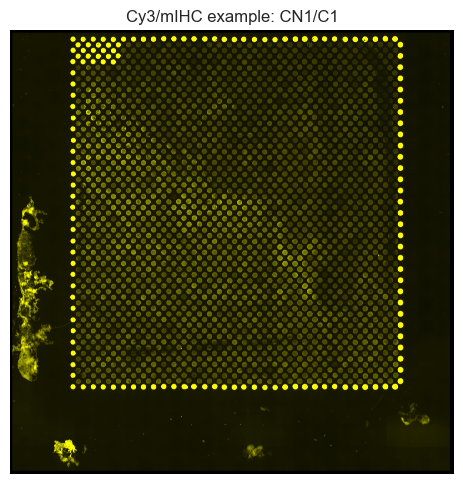

In [15]:
# check for IHC/Cy3 images in byArray
ihc_count = 0
ihc_example = None
for slide_dir in sorted((DATA / 'byArray').iterdir()):
    if not slide_dir.is_dir():
        continue
    for pos_dir in sorted(slide_dir.iterdir()):
        if not pos_dir.is_dir():
            continue
        cy3 = list(pos_dir.glob('*Cy3*small*.jpg'))
        if cy3:
            ihc_count += 1
            if ihc_example is None:
                ihc_example = cy3[0]

print(f'subarrays with Cy3/mIHC images: {ihc_count}')
if ihc_example:
    img = Image.open(ihc_example)
    print(f'example: {ihc_example.name} ({img.size})')
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(f'Cy3/mIHC example: {ihc_example.parent.parent.name}/{ihc_example.parent.name}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    img.close()

---

## summary

### what exists
- 94 patients in Clinical.xlsx with 54 columns (staging, survival, molecular subtypes, TIME, spatial archetypes)
- 47 slide arrays, 281 subarrays in byArray/, each containing H&E thumbnails, Cy3 images, spot coordinates, count data
- 281 count matrices in rawCountsMatrices/ (bz2-compressed TSVs with Ensembl gene IDs, GRCh38/hg38 GENCODE v38)
- count values are floats (log-normalized + batch corrected, paper p15), not raw integer counts
- 94 subarrays with expert morphological annotations (annotBySpot.RDS): 17 tissue categories + background, pixel fractions per spot
- mIHC (Cy3) images available per subarray - not used in current pipeline, reserved for future integration
- 281 full-resolution H&E WSIs in Images/imagesHD/ (31744x31744, 0.2774 um/pixel), 279 matched to subarrays (TNBC23, TNBC64 missing)
- platform: original Spatial Transcriptomics AB (1934 spots/array, 100um diameter, 200um center-to-center) - not 10x Visium

### basic QC (all 281 arrays)
- spots/array: nearly uniform at 1934 (the full ST array grid)
- median UMI/array: mean 3952, range 81-16748 (log-normalized values)
- median genes/spot: mean 1570, range 67-4919
- sparsity: ~89% (typical for spot-based ST)

### batch structure
- 8 high UMI outliers concentrated on L002 and L004 sequencing lanes
- 8 low spot-count arrays on L003 and L004
- sequencing depth varies by plate/lane - batch effect is visible and must be accounted for

### clinical missingness
- core fields (staging, grade, ER/PR/HER2, Ki67) nearly complete (0-1 missing)
- relapse/death fields missing for patients without events (expected)
- 1 patient missing TIME classification ("nd")
- 9 patients missing expression-based TIME/subtype classification

### resolved
- one array (median UMI = 81) is essentially dead - excluded from downstream
- rawCountsMatrices/ contains pre-normalized values, not raw counts - raw integer counts found in byArray/{slide}/{subarray}/selection.RData (tissue-filtered, ~1075 spots x 27567 genes, median 16492 UMI/spot)
- 2 subarrays (TNBC23/CN12/C1, TNBC64/CN32/D2) have no matching HD image - excluded from downstream